## notebook for investigating trend in MHT

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os
# plottng
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import palettable.colorbrewer as cb 


import scipy
import scipy.stats as stats
from scipy.stats import pearsonr

from statsmodels.tsa.stattools import ccf
from amocatlas import read

from process_raw_data import MHT_selection, MHT_lat_selection, lowpass_filter #, calc_ci

from stats_plots import acf_calc_plot, integral_time_scale, critical_r, plot_hovmöller, plot_crosscorr, plot_timeseries, plot_shifted_timeseries, lagged_std, zero_lag_corr

In [2]:
ds = read.calafat2025()

lats = ds.LATITUDE.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats][1:]


MHT_dict = MHT_selection(ds, statistics=True, anomalies=True, time_mean=True, drop65=True)

lats = MHT_dict["lats"]
mht = MHT_dict["MHT"] 
mht_stats = MHT_dict["MHT_statistics"] 
mht_mean = mht_stats["mean"] # this is mean over posterior samples!
mht_time_mean = mht_stats["time_mean"]
mht_all_mean = mht_time_mean.mean(dim="posterior_samples")

mht_std = mht_stats["std"]
mht_ci = mht_stats["ci"]

# mht_anom = MHT_dict["MHT_anom"]
# choose one lat: 
lat_sel = 5
MHT_lat = MHT_lat_selection(MHT_dict, lat=lat_sel, ci=90, anomalies=True)

mht_lat = MHT_lat["MHT_lat"]
mht_lat_stats = MHT_lat["MHT_lat_statistics"] 
mht_lat_mean = MHT_lat["MHT_lat_statistics"]["mean"]
mht_lat_time_mean = MHT_lat["MHT_lat_statistics"]["time_mean"]


seasonal_clim = mht_mean.groupby('TIME.month').mean(dim='TIME')  # shape: (12, lat)
seasonal_clim_prob = mht.groupby('TIME.month').mean(dim='TIME')  # shape: (12, lat, posterior_samples)
# subtract it from each timestep
mht_anom = mht_mean.groupby('TIME.month') - seasonal_clim
mht_anom_prob = mht.groupby('TIME.month') - seasonal_clim_prob

mht_deseasonalized = mht_anom + mht_all_mean
mht_deseasonalized_prob = mht_anom_prob + mht_all_mean

mht_smooth = lowpass_filter(mht_deseasonalized)
mht_smooth_prob = lowpass_filter(mht_deseasonalized_prob)
mht_smooth_anom = lowpass_filter(mht_anom)
mht_smooth_anom_prob = lowpass_filter(mht_anom_prob)

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



In [3]:
ds = mht_smooth
ds_anom = mht_smooth_anom
ds_anom_prob = mht_smooth_anom_prob


In [ ]:
lats
cmap = plt.cm.coolwarm 

colors = [cmap(i / (len(lats) - 1)) for i in range(len(lats))]

label_map = {lat: lat_labels[i] for i, lat in enumerate(lats)}


In [23]:
def plot_timeseries(ds, timescale="years", title="MHT", show_trend=True):
    """
    Plot MHT time series per latitude, optionally overlaid with linear trends.

    Parameters
    ----------
    ds : xarray.DataArray
        Data with dims (lat, TIME) matching `lats`/`colors` ordering.
    timescale : str
        "years" or "days" — only used if show_trend=True (controls slope units).
    title : str
        Plot title.
    show_trend : bool
        If True, fit and overlay a linear trend per latitude (dashed line, legend
        shows slope). If False, just plot the raw time series per latitude.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    if show_trend:
        if timescale == "years":
            time_numeric = (ds['TIME'] - ds['TIME'][0]) / np.timedelta64(1, 'D') / 365.25
            slope_unit = "yr"
        elif timescale == "days":
            time_numeric = (ds['TIME'] - ds['TIME'][0]) / np.timedelta64(1, 'D')
            slope_unit = "day"
        else:
            raise ValueError("timescale must be 'years' or 'days'")

    for i, lat_dim in enumerate(ds.lat):
        lat = lat_dim.LATITUDE.values
        color = colors[np.where(lats == lat)[0][0]]

        if show_trend:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                time_numeric, ds.values[i, :]
            )
            trend = slope * time_numeric + intercept

            ax.plot(ds.TIME, ds.values[i, :], color=color, alpha=0.3)
            ax.plot(
                ds.TIME,
                trend,
                label=f"{lat}, slope: {slope:.0e} PW/{slope_unit}",
                color=color,
                linestyle="--",
                zorder=5,
                linewidth=2,
            )
        else:
            ax.plot(ds.TIME, ds.values[i, :], color=color, label=f"{lat}")

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("MHT")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    return fig, ax

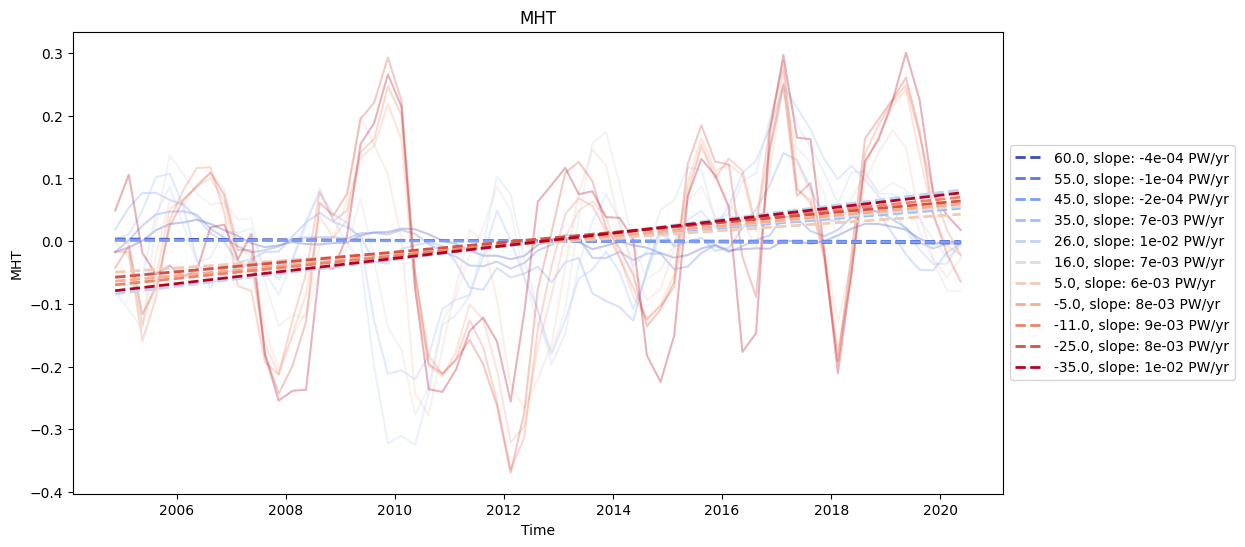

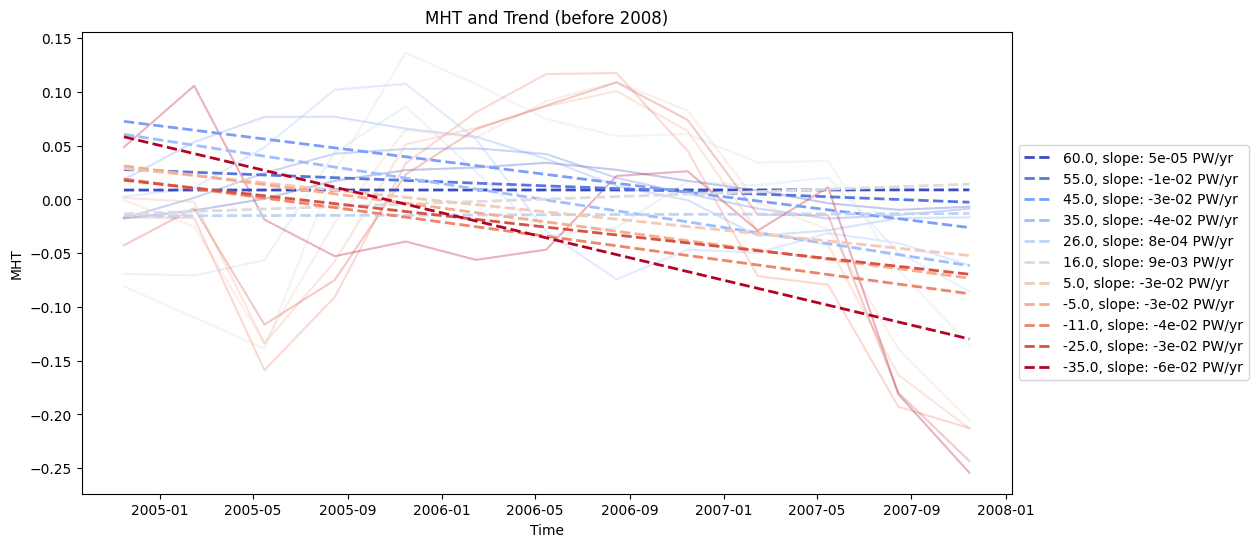

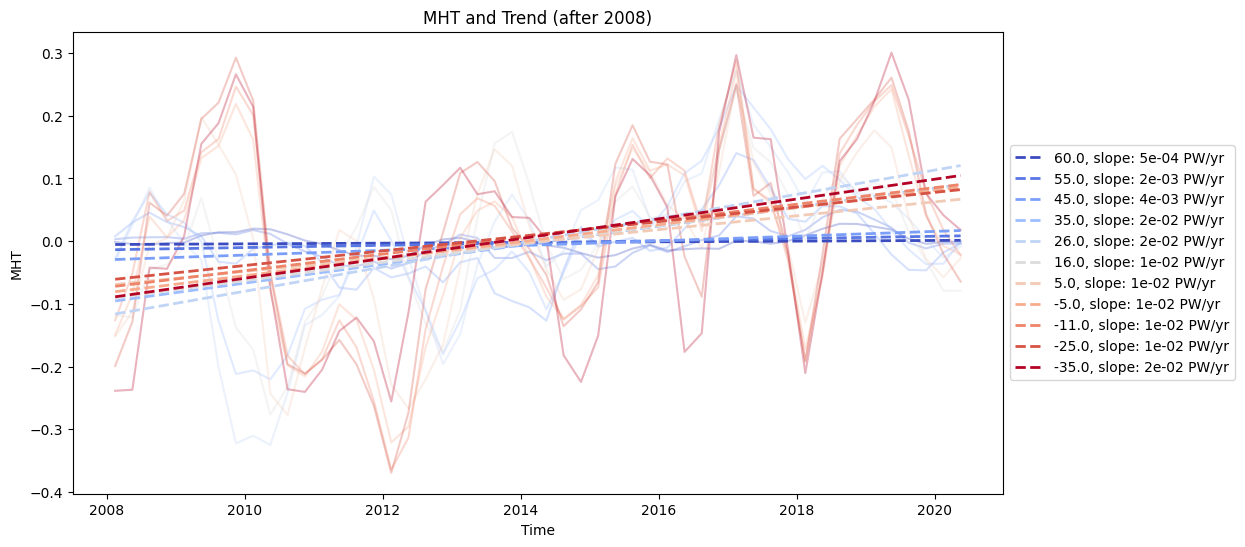

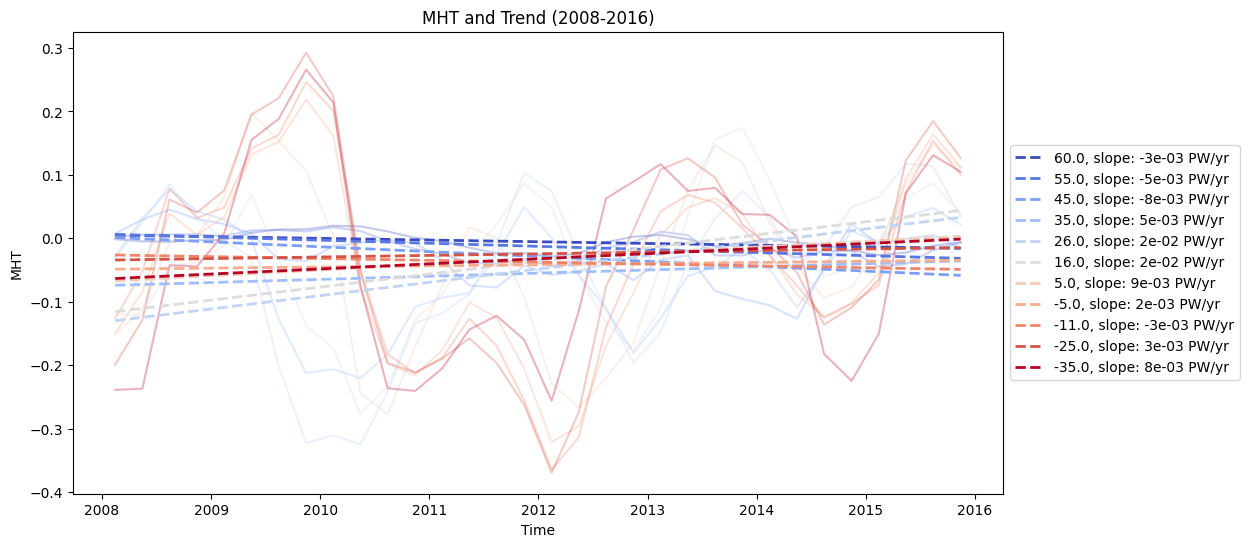

In [24]:
year = "2008"
fig, ax = plot_timeseries(ds_anom, timescale="years")
fig, ax = plot_timeseries(ds_anom.sel(TIME=slice(None, f"{year}-01-01")), timescale="years", title=f"MHT and Trend (before {year})")
fig, ax = plot_timeseries(ds_anom.sel(TIME=slice(f"{year}-01-01", None)), timescale="years", title=f"MHT and Trend (after {year})")
fig, ax = plot_timeseries(ds_anom.sel(TIME=slice(f"{year}-01-01", "2016-01-01")), timescale="years", title=f"MHT and Trend ({year}-2016)")
# fig, ax = plot_trend(ds_anom, timescale="years", title="MHT Anomalies and Trend")

In [25]:
def print_extremes(ds, percentile=10, extreme="lowest"):
    """
    Print the lowest or highest percentile of MHT values for each latitude.
s
    Parameters
    ----------
    ds : xarray.DataArray
        DataArray with dimensions (latitude, TIME)
    percentile : float
        Percentage of points to print (default: 10)
    extreme : str
        "lowest" or "highest"
    """

    n_points = max(1, int(np.ceil(ds.sizes["TIME"] * percentile / 100)))

    for lat in ds.LATITUDE.values:
        values = ds.sel(LATITUDE=lat).values
        times = ds.TIME.values

        if extreme == "lowest":
            idx = np.argsort(values)[:n_points]
        elif extreme == "highest":
            idx = np.argsort(values)[-n_points:][::-1]
        else:
            raise ValueError("extreme must be 'lowest' or 'highest'")

        print(f"\nLatitude {lat} ({extreme} {percentile}%):")
        print("-" * 40)
        for j in idx:
            print(f"{times[j]}   {values[j]:.3f}")
            
sel_lats = [35, 26, 5, -25]
ds_sel = ds.sel(LATITUDE=sel_lats)
print_extremes(ds_sel, percentile=5, extreme="lowest")



Latitude 35.0 (lowest 5%):
----------------------------------------
2010-05-16T00:00:00.000001907   0.849
2009-11-15T00:00:00.000000954   0.858
2010-02-14T00:00:00.000001907   0.864
2010-08-15T00:00:00.000001907   0.887

Latitude 26.0 (lowest 5%):
----------------------------------------
2010-05-16T00:00:00.000001907   0.815
2009-11-15T00:00:00.000000954   0.818
2010-02-14T00:00:00.000001907   0.830
2010-08-15T00:00:00.000001907   0.898

Latitude 5.0 (lowest 5%):
----------------------------------------
2010-08-15T00:00:00.000001907   0.632
2012-05-15T23:59:59.999996901   0.642
2010-05-16T00:00:00.000001907   0.666
2012-02-14T23:59:59.999996901   0.680

Latitude -25.0 (lowest 5%):
----------------------------------------
2012-02-14T23:59:59.999996901   -0.038
2012-05-15T23:59:59.999996901   0.057
2011-11-15T00:00:00.000000954   0.068
2007-11-15T00:00:00.000000954   0.088


In [26]:
for i, lat in enumerate(ds.lat):
    print(i, lat.LATITUDE.values)

0 60.0
1 55.0
2 45.0
3 35.0
4 26.0
5 16.0
6 5.0
7 -5.0
8 -11.0
9 -25.0
10 -35.0


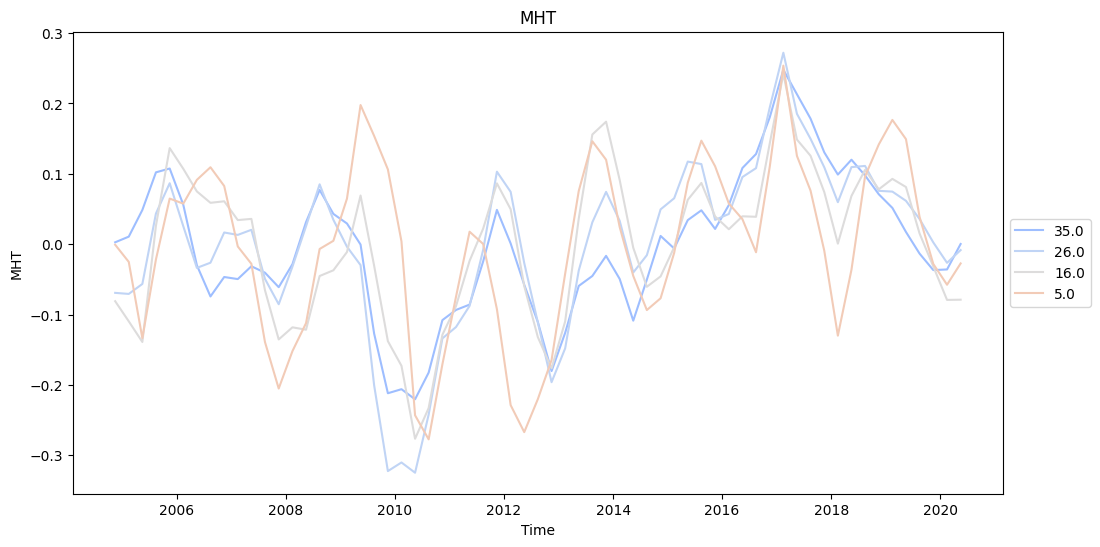

In [29]:
fig, ax = plot_timeseries(ds_anom.isel(lat=slice(3,7)), timescale="years", show_trend=False)
